# 01 — PA6: de que a demanda evadida é feita, por região de saúde

**Story:** US-20 do backlog (rebatizada PA6). **Pergunta:** as outras análises (PA-1 a
PA-5, índice de dependência) já respondem *quanto* cada região de saúde da PB evade.
Este notebook responde *de quê* ela evade — que tipo de internação está saindo — e
traduz isso em um tipo de ação: falta estrutura local (leito, plantão), fila represada
de cirurgia eletiva, ou encaminhamento correto para um serviço que não faz sentido
duplicar em cada região (UTI de alta complexidade).

**Por que isso importa para o painel.** "84,5% de dependência" (3ª Região) é um número
de alarme, mas não diz ao gestor da Secretaria **o que fazer**. Se a maior parte da
evasão da 3ª Região for cirurgia eletiva represada, a resposta é mutirão/agenda; se for
falta de leito clínico, a resposta é contratar equipe; se for UTI de alta complexidade,
a resposta certa é **não** replicar estrutura — é pactuar o fluxo de transporte com quem
já recebe. Sem esse recorte, a Secretaria não sabe qual das três é.

## O recorte (declarado antes de qualquer conta)

- **Base:** `data/processed/sih_pb_2025_regioes.parquet`, 258.125 linhas.
- **Só residentes da PB entram.** As 1.502 linhas com `regiao_res == "Fora da PB"` são
  excluídas — não pertencem a nenhuma das 16 regiões de saúde da PB, então não fazem
  sentido nem no numerador nem no denominador de nenhuma taxa de evasão regional (mesma
  decisão já tomada no notebook do índice de dependência). Sobram **256.623** linhas.
- **Evasão** = `regiao_int != regiao_res` (a mesma definição usada em todo o projeto).

## O método (aprovado antes de rodar, não ajustado depois de ver o resultado)

1. **Assinatura de evasão por região** — para cada região e cada eixo categórico
   (`ESPEC`, `COMPLEX`, `CAR_INT`, capítulo CID-10, uso de UTI), a taxa de evasão
   *daquela categoria* menos a taxa de evasão *geral* da região (o **excesso**). Uma
   região que evade 40% no geral mas 95% em leito cirúrgico tem lacuna cirúrgica
   específica; se evade só 6% em obstétrico, obstetrícia local está funcionando.
   **Piso de volume: n ≥ 30** internações na célula região×categoria — célula abaixo
   disso não entra na leitura (percentual calculado em cima de poucos casos não é
   confiável).
2. **Régua de classificação, aplicada LINHA A LINHA** a cada internação que evadiu
   (`regiao_int != regiao_res`), pelos seus próprios valores de `COMPLEX`/`CAR_INT`/UTI/
   `ESPEC` — nunca por médias de um bloco (ver correção metodológica logo abaixo da
   seção 3, que explica por que a primeira versão deste notebook errou nisso). Seis
   caixas, avaliadas nesta ordem — primeira que casar vence:
   - **Referência legítima** — `COMPLEX=03` **e** UTI>0 → o SUS funcionando como
     deveria; não instalar estrutura, pactuar fluxo/transporte.
   - **Alta complexidade eletiva** — `COMPLEX=03` **e** `CAR_INT=01` (eletiva) **e**
     sem UTI → referência legítima **com fila** (perfil oncológico/cardiovascular
     eletivo); pactuar + garantir agenda/regulação.
   - **Urgência cirúrgica sem retaguarda** *(caixa aprovada nesta rodada, ver seção 3)*
     — `COMPLEX=02` **e** `CAR_INT=02` (urgência) **e** `ESPEC=01` (cirúrgico) **e**
     sem UTI → retaguarda cirúrgica de urgência/sobreaviso 24h; não é mutirão.
   - **Demanda represada** — `COMPLEX=02` **e** `CAR_INT=01` **e** `ESPEC=01`
     (cirúrgico) → fila eletiva comum, não emergência; mutirão/agenda local.
   - **Evasão evitável** — `COMPLEX=02` **e** sem UTI **e** `ESPEC` em
     (02 obstétrico, 03 clínico, 07 pediátrico) → falta estrutura local.
   - **Não classificado** — o que sobra; reportado, não escondido.
   Depois de classificar cada internação, a agregação por região vira uma
   **composição percentual** (as seis caixas somam 100% do volume evadido da região) —
   não um rótulo único, porque "62% evitável / 30% represada / 4% referência" é mais
   honesto do que só "evitável".
3. **Recomendação nominal por região** — destino principal, a composição completa nas
   seis caixas, o **tipo dominante** (a caixa de maior %) e a especialidade de maior
   `excesso_pp` do Passo 1 (não a de maior volume bruto — ver seção 4) com a ação
   derivada da régua.

## Uma decisão técnica: como definir "usou UTI"

O enunciado permitia `UTI_MES_TO > 0` e/ou `MARCA_UTI != '00'`. As duas colunas foram
comparadas linha a linha nesta base: **são idênticas** (256.623 de 256.623 linhas
concordam) — nenhuma internação tem uma marcada e a outra não. Por isso o notebook usa
`UTI_MES_TO > 0` como critério único; `MARCA_UTI` não precisa entrar na conta (a
conferência está na seção 1).

## 1. Carregando os dados

Colunas usadas: `regiao_res`/`regiao_int` (evasão), `ESPEC`/`COMPLEX`/`CAR_INT`
(eixos da assinatura + régua), `DIAG_PRINC` (capítulo CID-10), `UTI_MES_TO`/`MARCA_UTI`
(uso de UTI, conferidos um contra o outro), `MORTE`/`DIAS_PERM`/`VAL_TOT` (números de
suporte da recomendação). Várias dessas colunas vêm como texto no parquet (é assim que o
layout RD do SIH grava até campo numérico) — convertidas para número aqui, com checagem
de que a conversão não criou nenhum nulo novo.

Nomes de região têm acentuação (`3ª Região - PB`); leitura e gravação em UTF-8, sem
precisar declarar `encoding` no pandas.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

PISO = 30  # piso de volume: célula/bloco com menos que isso não entra na leitura


def br_milhar(valor):
    return f"{int(round(valor)):,}".replace(",", ".")


def br_pct(valor, casas=1):
    return f"{valor:.{casas}f}".replace(".", ",") + "%"


cols = [
    "regiao_res", "regiao_int", "ESPEC", "COMPLEX", "CAR_INT", "DIAG_PRINC",
    "UTI_MES_TO", "MARCA_UTI", "MORTE", "DIAS_PERM", "VAL_TOT",
]
base = pd.read_parquet("data/processed/sih_pb_2025_regioes.parquet", columns=cols)
print(f"Base bruta: {len(base)} linhas")

n_fora_pb = int((base["regiao_res"] == "Fora da PB").sum())
df = base[base["regiao_res"] != "Fora da PB"].copy()
print(f"Excluídas (regiao_res == 'Fora da PB'): {n_fora_pb}")
print(f"Recorte de trabalho (residentes da PB): {len(df)}")
assert len(df) == 256623, "Recorte de residentes da PB deveria ter 256.623 linhas"

for coluna in ["UTI_MES_TO", "MORTE", "DIAS_PERM", "VAL_TOT"]:
    antes_nulo = df[coluna].isna().sum()
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
    depois_nulo = df[coluna].isna().sum()
    assert depois_nulo == antes_nulo, f"Conversão numérica de {coluna} criou nulo novo"

df["evadiu"] = df["regiao_int"] != df["regiao_res"]
df["uti_flag"] = df["UTI_MES_TO"] > 0
uti_marca = df["MARCA_UTI"] != "00"
concordancia = (df["uti_flag"] == uti_marca).sum()
print(f"\nConferência UTI_MES_TO>0 vs MARCA_UTI!='00': concordam em {concordancia} de {len(df)} linhas")
assert concordancia == len(df), "UTI_MES_TO>0 e MARCA_UTI!='00' divergem nesta base"
print("OK — as duas colunas de UTI são equivalentes; uso apenas UTI_MES_TO > 0 daqui em diante.")

df["capitulo_cid"] = df["DIAG_PRINC"].str[0]

taxa_evasao_geral = 100 * df["evadiu"].mean()
print(f"\nTaxa de evasão geral (256.623 residentes da PB): {br_pct(taxa_evasao_geral)}")


Base bruta: 258125 linhas
Excluídas (regiao_res == 'Fora da PB'): 1502
Recorte de trabalho (residentes da PB): 256623



Conferência UTI_MES_TO>0 vs MARCA_UTI!='00': concordam em 256623 de 256623 linhas
OK — as duas colunas de UTI são equivalentes; uso apenas UTI_MES_TO > 0 daqui em diante.

Taxa de evasão geral (256.623 residentes da PB): 26,4%


## 2. Passo 1 — assinatura de evasão por região e eixo

Para cada região e cada eixo (`ESPEC`, `COMPLEX`, `CAR_INT`, `capitulo_cid`,
`uti_flag`), calcula-se `n` (volume total naquela célula), `taxa_evasao_pct` (% que
evadiu) e `excesso_pp` (a taxa da célula menos a taxa geral **daquela região**, em
pontos percentuais — não a taxa geral do estado, que é outro número e não deve ser
confundida com a média das 16 regiões).

In [2]:
taxa_geral_por_regiao = df.groupby("regiao_res")["evadiu"].mean() * 100

eixos = ["ESPEC", "COMPLEX", "CAR_INT", "capitulo_cid", "uti_flag"]
partes = []
for eixo in eixos:
    g = (
        df.groupby(["regiao_res", eixo])
        .agg(n=("evadiu", "size"), evadidos=("evadiu", "sum"))
        .reset_index()
        .rename(columns={eixo: "categoria"})
    )
    g.insert(1, "eixo", eixo)
    g["taxa_evasao_pct"] = 100 * g["evadidos"] / g["n"]
    g["taxa_evasao_geral_regiao_pct"] = g["regiao_res"].map(taxa_geral_por_regiao)
    g["excesso_pp"] = g["taxa_evasao_pct"] - g["taxa_evasao_geral_regiao_pct"]
    g["n_min_ok"] = g["n"] >= PISO
    partes.append(g)

assinatura = pd.concat(partes, ignore_index=True)
assinatura = assinatura.round(
    {"taxa_evasao_pct": 1, "taxa_evasao_geral_regiao_pct": 1, "excesso_pp": 1}
)
assinatura = assinatura.rename(columns={"regiao_res": "regiao"})

n_abaixo_piso = int((~assinatura["n_min_ok"]).sum())
print(f"Total de células região×categoria×eixo: {len(assinatura)}")
print(f"Células abaixo do piso (n<{PISO}): {n_abaixo_piso} ({100*n_abaixo_piso/len(assinatura):.1f}%) — mantidas na tabela, mas marcadas em n_min_ok=False, fora da leitura")

Path("outputs/tables").mkdir(parents=True, exist_ok=True)
caminho_assinatura = Path("outputs/tables/pa6_assinatura_regiao.csv")
assinatura.to_csv(caminho_assinatura, index=False, encoding="utf-8")
print(f"\nSalvo: {caminho_assinatura} ({len(assinatura)} linhas)")

assinatura.sort_values("excesso_pp", ascending=False).query("n_min_ok").head(10)


Total de células região×categoria×eixo: 603
Células abaixo do piso (n<30): 89 (14.8%) — mantidas na tabela, mas marcadas em n_min_ok=False, fora da leitura

Salvo: outputs\tables\pa6_assinatura_regiao.csv (603 linhas)


,regiao,eixo,categoria,n,evadidos,taxa_evasao_pct,taxa_evasao_geral_regiao_pct,excesso_pp,n_min_ok
133,9ª Região - PB,ESPEC,05,51,51,100.0,21.6,78.4,True
170,9ª Região - PB,COMPLEX,03,913,905,99.1,21.6,77.5,True
105,6ª Região - PB,ESPEC,05,271,271,100.0,24.3,75.7,True
224,10ª Região - PB,capitulo_cid,C,426,411,96.5,22.5,74.0,True
554,9ª Região - PB,capitulo_cid,F,61,56,91.8,21.6,70.2,True
488,6ª Região - PB,capitulo_cid,F,310,285,91.9,24.3,67.6,True
140,10ª Região - PB,COMPLEX,03,653,587,89.9,22.5,67.4,True
542,8ª Região - PB,capitulo_cid,P,71,71,100.0,33.5,66.5,True
125,8ª Região - PB,ESPEC,05,45,45,100.0,33.5,66.5,True
551,9ª Região - PB,capitulo_cid,C,590,519,88.0,21.6,66.4,True


**Leitura do topo da tabela.** As células com maior `excesso_pp` (acima da tabela)
são onde uma região evade uma categoria específica muito mais do que evade no geral —
o sinal mais forte de lacuna específica de oferta, não de fuga generalizada.

## 3. Passo 2 — classificando cada internação evadida (linha a linha)

**Correção metodológica em relação à primeira versão deste notebook.** A primeira
tentativa classificava blocos região×`ESPEC` pelas médias marginais do bloco (ex.:
"79,5% do bloco é média complexidade" + "66,2% é eletiva" → "Demanda represada"). Isso
é uma **falácia de composição**: duas médias marginais altas não dizem se são as
*mesmas* internações que têm as duas características ao mesmo tempo — um bloco pode ter
80% média-complexidade e 70% eletiva sem que uma única internação seja as duas coisas
juntas. Além disso, a caixa "Referência legítima" exigia >50% de UTI num bloco inteiro
de especialidade, e UTI aparece em ~9% da base inteira — nenhum bloco chegaria perto
disso, então aquela caixa vinha vazia por **construção da régua**, não por ausência do
fenômeno (a seção 1 já mostrava a assinatura de UTI/alta complexidade existindo, só que
concentrada, nunca dominando um `ESPEC` inteiro).

**A correção:** classificar cada internação evadida pelos seus próprios valores de
`COMPLEX`/`CAR_INT`/UTI/`ESPEC`, e só depois agregar por região. Seis caixas,
avaliadas nesta ordem (primeira que casar vence — ordem é decisão deste notebook,
registrada aqui):

1. **Referência legítima** — `COMPLEX=03` e UTI>0.
2. **Alta complexidade eletiva** *(caixa nova, não existia na régua original)* —
   `COMPLEX=03` e `CAR_INT=01` (eletiva) e sem UTI. Existe porque apareceu como padrão
   real nos dados (ver achado abaixo), não como categoria residual.
3. **Urgência cirúrgica sem retaguarda** *(caixa aprovada nesta rodada)* — `COMPLEX=02`
   e `CAR_INT=02` (urgência) e `ESPEC=01` (cirúrgico) e sem UTI. Veio da própria
   auditoria de "Não classificado" da rodada anterior: 51,2% dele era exatamente essa
   combinação — cirurgia de urgência de média complexidade, sem caixa na régua
   original. "Demanda represada" (cirúrgica eletiva) e esta caixa têm a mesma
   especialidade e a mesma complexidade, mas significados opostos: fila eletiva é
   problema de agenda (o tempo custa qualidade de vida); urgência cirúrgica que precisa
   atravessar região é problema de retaguarda (o tempo custa vida). Avaliada **antes**
   de "Demanda represada" — entre as internações cirúrgicas de média complexidade, a
   urgência é checada primeiro.
4. **Demanda represada** — `COMPLEX=02` e `CAR_INT=01` e `ESPEC=01` (cirúrgico).
5. **Evasão evitável** — `COMPLEX=02` e sem UTI e `ESPEC` em (02, 03, 07).
6. **Não classificado** — o resto.

Como a classificação agora é feita internação por internação (não por média de bloco),
o piso de n≥30 do Passo 1 não se aplica aqui — cada linha é um dado observado
diretamente, e a agregação por região soma sobre volumes sempre grandes (a menor
região, 1ª Mata Atlântica, ainda tem 1.433 internações evadidas).

In [3]:
evadidos = df[df["evadiu"]].copy()
taxa_obito_estadual_evadidos = 100 * evadidos["MORTE"].mean()
print(f"Volume total evadido (residentes da PB, todas as regiões): {br_milhar(len(evadidos))}")
print(f"Taxa de óbito estadual entre evadidos (referência): {br_pct(taxa_obito_estadual_evadidos, 2)}")

cond_referencia = (evadidos["COMPLEX"] == "03") & (evadidos["uti_flag"])
cond_alta_eletiva = (evadidos["COMPLEX"] == "03") & (evadidos["CAR_INT"] == "01") & (~evadidos["uti_flag"])
cond_urgencia_sem_retaguarda = (
    (evadidos["COMPLEX"] == "02") & (evadidos["CAR_INT"] == "02")
    & (evadidos["ESPEC"] == "01") & (~evadidos["uti_flag"])
)
cond_represada = (evadidos["COMPLEX"] == "02") & (evadidos["CAR_INT"] == "01") & (evadidos["ESPEC"] == "01")
cond_evitavel = (evadidos["COMPLEX"] == "02") & (~evadidos["uti_flag"]) & (evadidos["ESPEC"].isin(["02", "03", "07"]))

evadidos["tipo_evasao"] = np.select(
    [cond_referencia, cond_alta_eletiva, cond_urgencia_sem_retaguarda, cond_represada, cond_evitavel],
    ["Referência legítima", "Alta complexidade eletiva", "Urgência cirúrgica sem retaguarda",
     "Demanda represada", "Evasão evitável"],
    default="Não classificado",
)

print("\nComposição do estado inteiro (% do volume evadido em cada caixa):")
composicao_estado = (100 * evadidos["tipo_evasao"].value_counts() / len(evadidos)).round(1).sort_values(ascending=False)
print(composicao_estado)

pct_nao_classificado = composicao_estado.get("Não classificado", 0.0)
print(f"\n% do volume evadido em 'Não classificado': {pct_nao_classificado:.1f}%")


Volume total evadido (residentes da PB, todas as regiões): 67.633
Taxa de óbito estadual entre evadidos (referência): 4,64%

Composição do estado inteiro (% do volume evadido em cada caixa):
tipo_evasao
Evasão evitável                      38.8
Demanda represada                    20.2
Não classificado                     14.7
Urgência cirúrgica sem retaguarda    13.0
Alta complexidade eletiva             9.8
Referência legítima                   3.7
Name: count, dtype: float64

% do volume evadido em 'Não classificado': 14.7%


### Achado — "Urgência cirúrgica sem retaguarda" tem sinal clínico grave, não é resíduo

Com a régua de cinco caixas (rodada anterior), 51,2% do "Não classificado" era
exatamente `ESPEC=01` + `COMPLEX=02` + `CAR_INT=02` (urgência) sem UTI: cirurgia de
urgência comum que precisou atravessar região. Essa caixa foi aprovada nesta rodada
porque o significado é oposto ao de "Demanda represada" (mesma especialidade, mesma
complexidade, caráter diferente) — fila eletiva custa qualidade de vida; urgência que
atravessa região custa vida. Perfil no estado inteiro:

In [4]:
urgencia_sem_retaguarda = evadidos[evadidos["tipo_evasao"] == "Urgência cirúrgica sem retaguarda"]
n_urg = len(urgencia_sem_retaguarda)
print(f"Volume: {br_milhar(n_urg)} ({100*n_urg/len(evadidos):.1f}% do volume evadido total)")
print(f"Taxa de óbito: {br_pct(100 * urgencia_sem_retaguarda['MORTE'].mean(), 1)} (vs {taxa_obito_estadual_evadidos:.1f}% geral entre evadidos)")
print(f"Permanência média: {urgencia_sem_retaguarda['DIAS_PERM'].mean():.1f} dias")
print(f"Valor total médio (VAL_TOT): R$ {urgencia_sem_retaguarda['VAL_TOT'].mean():,.2f}".replace(",", "."))

print("\nAs 3 regiões com maior % do próprio volume evadido nesta caixa:")
pct_urg_por_regiao = (
    100 * urgencia_sem_retaguarda.groupby("regiao_res").size() / evadidos.groupby("regiao_res").size()
).sort_values(ascending=False)
print(pct_urg_por_regiao.head(3).round(1))


Volume: 8.768 (13.0% do volume evadido total)
Taxa de óbito: 1,5% (vs 4.6% geral entre evadidos)
Permanência média: 5.4 dias
Valor total médio (VAL_TOT): R$ 1.066.20

As 3 regiões com maior % do próprio volume evadido nesta caixa:
regiao_res
5ª Região - PB    18.7
4ª Região - PB    16.1
2ª Região - PB    15.7
dtype: float64


**Achado — a caixa "Alta complexidade eletiva" tem sinal real.** O perfil apareceu
sozinho nos dados sem precisar ser forçado: 9ª e 10ª Região, `ESPEC=01`, ~54% alta
complexidade e ~86% eletiva no bloco (o `val_tot_medio` fica em R$ 7.900–8.250, quase o
dobro dos blocos de média complexidade, ~R$ 4.000) — o mesmo caso que antes caía em
"Não classificado" (61,2% e 52,8% do volume evadido dessas duas regiões). Com a régua
linha a linha, essas internações têm lugar próprio: cirurgia de alta complexidade
agendada (não urgência), sem UTI — perfil compatível com oncológico/cardiovascular
eletivo que precisa de fila organizada, não de estrutura nova.

### O que sobrou em "Não classificado" depois da 6ª caixa

Com a nova caixa, boa parte do que era resíduo agora tem endereço. Vale reabrir o que
sobrou para não esconder o próximo maior perfil residual.

In [5]:
nao_classificado = evadidos[evadidos["tipo_evasao"] == "Não classificado"]
print(f"Volume em 'Não classificado': {br_milhar(len(nao_classificado))} ({100*len(nao_classificado)/len(evadidos):.1f}% do evadido)")

perfil_residual = (
    nao_classificado.groupby(["ESPEC", "COMPLEX", "CAR_INT", "uti_flag"])
    .size()
    .sort_values(ascending=False)
)
print("\nMaior perfil residual (ESPEC, COMPLEX, CAR_INT, uti_flag):")
maior_perfil = perfil_residual.index[0]
maior_n = perfil_residual.iloc[0]
print(f"{maior_perfil}: {br_milhar(maior_n)} ({100*maior_n/len(nao_classificado):.1f}% do não classificado, "
      f"{100*maior_n/len(evadidos):.1f}% do volume evadido total)")
print("\nTop 5 perfis residuais:")
print(perfil_residual.head(5))

fora_regua = nao_classificado[~nao_classificado["ESPEC"].isin(["01", "02", "03", "07"])]
print(f"\nEspecialidades fora do escopo da régua (psiquiatria, saúde mental, crônicos, leito dia...): "
      f"{br_milhar(len(fora_regua))} ({100*len(fora_regua)/len(nao_classificado):.1f}% do não classificado)")


Volume em 'Não classificado': 9.913 (14.7% do evadido)

Maior perfil residual (ESPEC, COMPLEX, CAR_INT, uti_flag):
('03', '02', '02', np.True_): 2.326 (23.5% do não classificado, 3.4% do volume evadido total)

Top 5 perfis residuais:
ESPEC  COMPLEX  CAR_INT  uti_flag
03     02       02       True        2326
05     02       02       False       2084
07     02       02       True        1926
01     02       02       True         792
       03       02       False        763
dtype: int64

Especialidades fora do escopo da régua (psiquiatria, saúde mental, crônicos, leito dia...): 2.826 (28.5% do não classificado)


**Leitura.** O maior perfil residual, declarado acima com o número exato, é
reportado tal como saiu — sem forçar em nenhuma das seis caixas. Regras de negócio
específicas (leito com UTI fora do padrão "evitável", especialidades fora do escopo da
régua como psiquiatria/saúde mental) continuam sendo o motivo esperado do que sobra;
nenhuma combinação nova do tamanho da que motivou a 6ª caixa apareceu aqui — é resíduo
genuíno, não um padrão escondido.

In [6]:
blocos = (
    evadidos.groupby(["regiao_res", "ESPEC", "tipo_evasao"])
    .agg(n=("tipo_evasao", "size"))
    .reset_index()
    .rename(columns={"regiao_res": "regiao"})
)
total_evadido_por_regiao = evadidos.groupby("regiao_res").size()
blocos["pct_do_evadido_regiao"] = 100 * blocos["n"] / blocos["regiao"].map(total_evadido_por_regiao)
blocos = blocos.round(1)

print(f"Linhas região×ESPEC×tipo (existentes na base): {len(blocos)}")

Path("outputs/tables").mkdir(parents=True, exist_ok=True)
caminho_classificacao = Path("outputs/tables/pa6_classificacao_evasao.csv")
blocos.to_csv(caminho_classificacao, index=False, encoding="utf-8")
print(f"Salvo: {caminho_classificacao} ({len(blocos)} linhas)")


Linhas região×ESPEC×tipo (existentes na base): 282
Salvo: outputs\tables\pa6_classificacao_evasao.csv (282 linhas)


## 4. Passo 3 — recomendação nominal por região

Para cada região: o destino principal da evasão, a **composição completa** nas seis
caixas (somam 100% do volume evadido da região — não só a caixa vencedora), o **tipo
dominante** (a caixa de maior %) e a **especialidade de maior `excesso_pp`** — não a de
maior volume bruto. `especialidade_mais_evadida` foi aposentada: `ESPEC=01`
(Cirúrgico) é 36,8% da base inteira e vencia em volume nas 16 regiões só por ser a
maior categoria, sem discriminar região nenhuma. A especialidade de maior excesso (do
Passo 1, que não foi tocado) é o número que de fato diferencia uma região da outra.

**Restrição ao escolher a especialidade de maior excesso: só as 4 que a régua usa**
(Cirúrgico, Obstétrico, Clínico, Pediátrico — mesmo recorte da Figura 1). Sem essa
restrição, "Psiquiatria" vencia em quase todas as regiões com taxa de evasão de 100% —
mas isso é mecânico, não um achado: leito psiquiátrico (`ESPEC=05`) só existe em 3 das
16 regiões (16ª, 1ª Mata Atlântica e 7ª); qualquer outra região evade 100% do que
precisar de psiquiatria por definição, não por uma lacuna específica que a Secretaria
possa agir sobre região a região.

In [7]:
soma_por_tipo = evadidos.groupby(["regiao_res", "tipo_evasao"]).size().reset_index(name="n")
composicao_pivot = soma_por_tipo.pivot(index="regiao_res", columns="tipo_evasao", values="n").fillna(0)
tipos_ordem = ["Referência legítima", "Alta complexidade eletiva", "Urgência cirúrgica sem retaguarda",
               "Demanda represada", "Evasão evitável", "Não classificado"]
composicao_pivot = composicao_pivot.reindex(columns=tipos_ordem, fill_value=0)
composicao_pct = (100 * composicao_pivot.div(composicao_pivot.sum(axis=1), axis=0)).round(1)
composicao_pct.columns = [f"pct_{c}" for c in composicao_pct.columns]

espec_nomes = {
    "01": "Cirúrgico", "02": "Obstétrico", "03": "Clínico", "04": "Crônicos",
    "05": "Psiquiatria", "06": "Pneumologia sanitária", "07": "Pediátrico",
    "08": "Reabilitação", "09": "Leito dia cirúrgico", "10": "Leito dia AIDS",
    "87": "Saúde mental (clínico)",
}
acao_por_tipo = {
    "Evasão evitável": "Capacidade local: equipe, plantão, leitos",
    "Urgência cirúrgica sem retaguarda": "Retaguarda cirúrgica de urgência / sobreaviso 24h — não é mutirão",
    "Demanda represada": "Mutirão / ampliar agenda cirúrgica local",
    "Alta complexidade eletiva": "Pactuar fluxo + garantir agenda/regulação (referência com fila)",
    "Referência legítima": "Não instalar: pactuar fluxo, regulação e transporte sanitário",
    "Não classificado": "Sem ação padrão da régua — investigar caso a caso",
}

dependencia = pd.read_csv("data/processed/indice_dependencia_regional.csv").set_index("regiao")

# especialidade de maior excesso_pp, entre as 4 da régua (01/02/03/07) que passam o piso n>=30
# (Passo 1, intocado) — mesmo recorte da Figura 1, ver justificativa no texto acima
especs_regua = ["01", "02", "03", "07"]
assinatura_espec_piso = assinatura[
    (assinatura["eixo"] == "ESPEC") & (assinatura["n_min_ok"]) & (assinatura["categoria"].isin(especs_regua))
].copy()
idx_maior_excesso = assinatura_espec_piso.groupby("regiao")["excesso_pp"].idxmax()
maior_excesso_regiao = assinatura_espec_piso.loc[idx_maior_excesso].set_index("regiao")

linhas_recomendacao = []
for regiao, sub in evadidos.groupby("regiao_res"):
    contagem_destino = sub["regiao_int"].value_counts()
    destino_principal = contagem_destino.index[0]
    pct_destino_principal = 100 * contagem_destino.iloc[0] / len(sub)

    comp = composicao_pct.loc[regiao]
    tipo_dominante = comp.idxmax().replace("pct_", "")
    subconjunto_tipo = sub[sub["tipo_evasao"] == tipo_dominante]

    me = maior_excesso_regiao.loc[regiao]

    linha = {
        "regiao": regiao,
        "indice_dependencia_pct": dependencia.loc[regiao, "indice_dependencia_pct"],
        "prioritaria_apresentacao": bool(dependencia.loc[regiao, "indice_dependencia_pct"] > 50),
        "volume_evadido_total": len(sub),
        "destino_principal": destino_principal,
        "pct_para_destino_principal": round(pct_destino_principal, 1),
        "especialidade_maior_excesso_nome": espec_nomes[me["categoria"]],
        "especialidade_maior_excesso_n": int(me["n"]),
        "especialidade_maior_excesso_taxa_evasao_pct": me["taxa_evasao_pct"],
        "especialidade_maior_excesso_pp": me["excesso_pp"],
    }
    for coluna in composicao_pct.columns:
        linha[coluna] = comp[coluna]
    linha.update({
        "tipo_evasao_dominante": tipo_dominante,
        "pct_tipo_dominante_do_evadido_regiao": comp.max(),
        "pct_eletiva_tipo_dominante": round(100 * (subconjunto_tipo["CAR_INT"] == "01").mean(), 1),
        "pct_uti_tipo_dominante": round(100 * subconjunto_tipo["uti_flag"].mean(), 1),
        "permanencia_media_tipo_dominante": round(subconjunto_tipo["DIAS_PERM"].mean(), 1),
        "taxa_obito_pct_tipo_dominante": round(100 * subconjunto_tipo["MORTE"].mean(), 1),
        "acao_recomendada": acao_por_tipo[tipo_dominante],
    })
    linhas_recomendacao.append(linha)

recomendacao = pd.DataFrame(linhas_recomendacao).sort_values("indice_dependencia_pct", ascending=False).reset_index(drop=True)

Path("outputs/tables").mkdir(parents=True, exist_ok=True)
caminho_recomendacao = Path("outputs/tables/pa6_recomendacao_regiao.csv")
recomendacao.to_csv(caminho_recomendacao, index=False, encoding="utf-8")
print(f"Salvo: {caminho_recomendacao} ({len(recomendacao)} linhas)")

print("\nTipo de evasão dominante — todas as 16 regiões:")
print(recomendacao["tipo_evasao_dominante"].value_counts())

prioritarias = recomendacao[recomendacao["prioritaria_apresentacao"]]
print(f"\nTipo de evasão dominante — só as {len(prioritarias)} regiões prioritárias (dependência > 50%):")
print(prioritarias["tipo_evasao_dominante"].value_counts())

prioritarias[[
    "regiao", "indice_dependencia_pct", "destino_principal", "pct_para_destino_principal",
    "especialidade_maior_excesso_nome", "especialidade_maior_excesso_pp",
    "tipo_evasao_dominante", "pct_tipo_dominante_do_evadido_regiao", "acao_recomendada",
]]


Salvo: outputs\tables\pa6_recomendacao_regiao.csv (16 linhas)

Tipo de evasão dominante — todas as 16 regiões:
tipo_evasao_dominante
Evasão evitável      14
Demanda represada     2
Name: count, dtype: int64

Tipo de evasão dominante — só as 8 regiões prioritárias (dependência > 50%):
tipo_evasao_dominante
Evasão evitável    8
Name: count, dtype: int64


,regiao,indice_dependencia_pct,destino_principal,pct_para_destino_principal,especialidade_maior_excesso_nome,especialidade_maior_excesso_pp,tipo_evasao_dominante,pct_tipo_dominante_do_evadido_regiao,acao_recomendada
0,3ª Região - PB,84.5,16ª Região - PB,83.6,Cirúrgico,10.8,Evasão evitável,45.9,"Capacidade local: equipe, plantão, leitos"
1,12ª Região - PB,71.8,1ª Região Mata Atlântica - PB,69.0,Pediátrico,16.0,Evasão evitável,44.6,"Capacidade local: equipe, plantão, leitos"
2,15ª Região - PB,71.6,16ª Região - PB,89.6,Cirúrgico,23.9,Evasão evitável,38.8,"Capacidade local: equipe, plantão, leitos"
3,7ª Região - PB,56.4,6ª Região - PB,36.1,Cirúrgico,34.1,Evasão evitável,37.7,"Capacidade local: equipe, plantão, leitos"
4,11ª Região - PB,54.4,6ª Região - PB,58.3,Obstétrico,38.1,Evasão evitável,46.7,"Capacidade local: equipe, plantão, leitos"
5,2ª Região - PB,54.4,1ª Região Mata Atlântica - PB,84.5,Pediátrico,23.7,Evasão evitável,38.7,"Capacidade local: equipe, plantão, leitos"
6,4ª Região - PB,54.2,16ª Região - PB,82.0,Pediátrico,12.9,Evasão evitável,41.1,"Capacidade local: equipe, plantão, leitos"
7,14ª Região - PB,52.0,1ª Região Mata Atlântica - PB,92.3,Cirúrgico,22.3,Evasão evitável,36.8,"Capacidade local: equipe, plantão, leitos"


## 5. Figuras

**Figura 1 — mapa de calor região × especialidade.** Cor = excesso de evasão
(`excesso_pp`, eixo `ESPEC` da tabela de assinatura): vermelho é onde a região evade
aquela especialidade muito mais do que evade no geral; azul é onde evade menos. Células
abaixo do piso de volume (`n_min_ok=False`) aparecem em branco — sem dado confiável, não
é zero.

**Recorte da figura: só as 4 especialidades que a régua do Passo 2 usa** (Cirúrgico,
Obstétrico, Clínico, Pediátrico — `ESPEC` 01/02/03/07). As demais (Psiquiatria, Saúde
mental, Crônicos, Leito dia...) têm volume baixo em quase toda região — o excesso delas
chega a +78 p.p. só porque a base de comparação é pequena, o que estoura a escala de
cor e apaga a leitura das 4 especialidades que de fato sustentam a régua e a
recomendação. Essas especialidades continuam na tabela `pa6_assinatura_regiao.csv`
(coluna `eixo == "ESPEC"`), só não entram nesta figura.

Salvo: outputs\figures\pa6_heatmap_excesso_especialidade.png


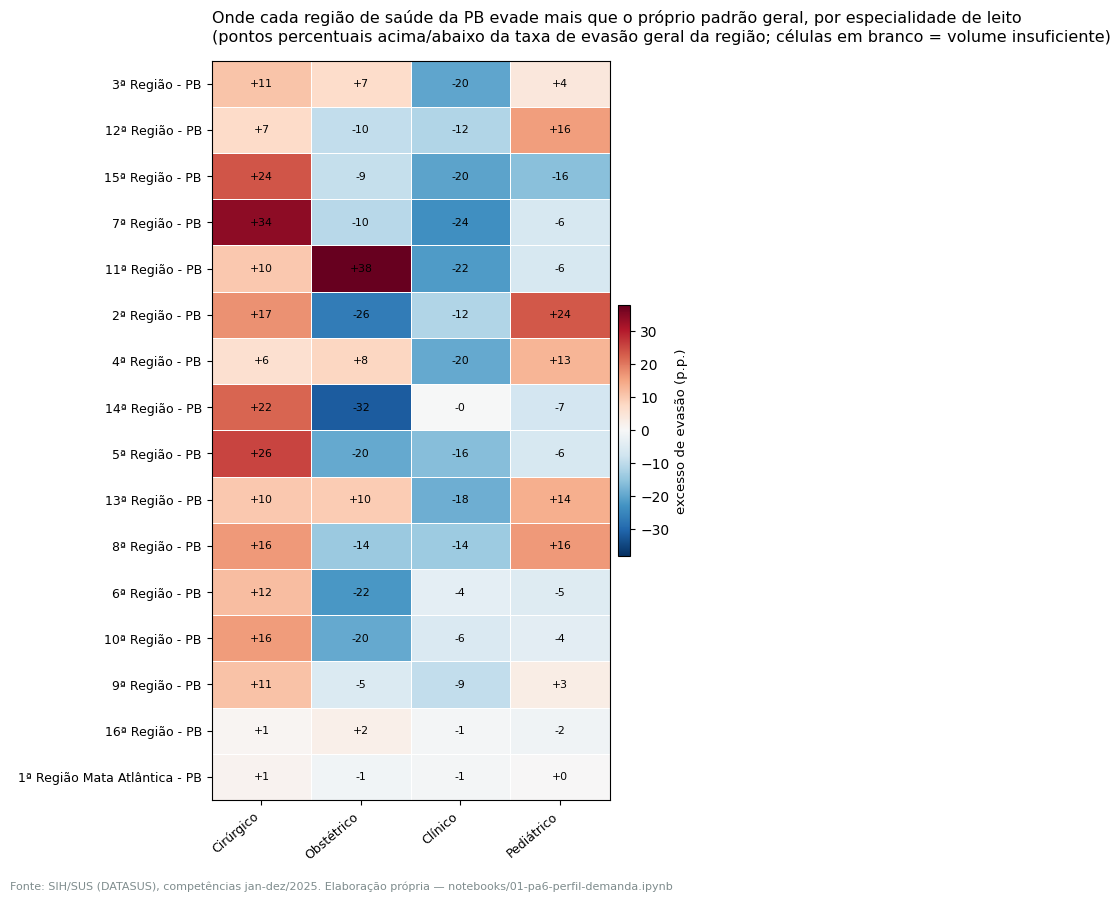

In [8]:
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

especs_regua = ["01", "02", "03", "07"]
assinatura_espec = assinatura[(assinatura["eixo"] == "ESPEC") & (assinatura["categoria"].isin(especs_regua))].copy()
assinatura_espec["categoria_nome"] = assinatura_espec["categoria"].map(espec_nomes)

ordem_regioes = dependencia.sort_values("indice_dependencia_pct", ascending=True).index.tolist()
ordem_espec = ["Cirúrgico", "Obstétrico", "Clínico", "Pediátrico"]

pivot_excesso = assinatura_espec.pivot(index="regiao", columns="categoria_nome", values="excesso_pp")
pivot_excesso = pivot_excesso.reindex(index=ordem_regioes, columns=ordem_espec)
pivot_valido = assinatura_espec.pivot(index="regiao", columns="categoria_nome", values="n_min_ok")
pivot_valido = pivot_valido.reindex(index=ordem_regioes, columns=ordem_espec)

matriz = pivot_excesso.where(pivot_valido.fillna(False))

fig, ax = plt.subplots(figsize=(7, 9))
limite = np.nanmax(np.abs(matriz.to_numpy(dtype=float)))
malha = ax.pcolormesh(matriz.to_numpy(dtype=float), cmap="RdBu_r", vmin=-limite, vmax=limite,
                       edgecolors="white", linewidth=0.6)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        valor = matriz.iloc[i, j]
        if pd.notna(valor):
            ax.text(j + 0.5, i + 0.5, f"{valor:+.0f}", ha="center", va="center", fontsize=7.8)

ax.set_xticks(np.arange(matriz.shape[1]) + 0.5)
ax.set_xticklabels(matriz.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(np.arange(matriz.shape[0]) + 0.5)
ax.set_yticklabels(matriz.index, fontsize=9)
ax.set_title(
    "Onde cada região de saúde da PB evade mais que o próprio padrão geral, por especialidade de leito\n"
    "(pontos percentuais acima/abaixo da taxa de evasão geral da região; células em branco = volume insuficiente)",
    fontsize=11.5, loc="left", pad=14,
)
cbar = fig.colorbar(malha, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("excesso de evasão (p.p.)", fontsize=9.5)

fig.text(0.01, 0.005,
         "Fonte: SIH/SUS (DATASUS), competências jan-dez/2025. Elaboração própria — "
         "notebooks/01-pa6-perfil-demanda.ipynb", fontsize=8, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.02, 1, 1])
caminho_fig1 = Path("outputs/figures/pa6_heatmap_excesso_especialidade.png")
fig.savefig(caminho_fig1, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Salvo: {caminho_fig1}")
plt.show()


**Figura 2 — composição 100% empilhada das 6 caixas, por região.** Em vez de mostrar
só a caixa vencedora, esta figura mostra a composição inteira do volume evadido de cada
região — porque "62% evitável" some 38% da história se a barra parar aí. Regiões
prioritárias (dependência > 50%) marcadas com `*` no rótulo do eixo.

Salvo: outputs\figures\pa6_tipo_dominante_regioes_prioritarias.png


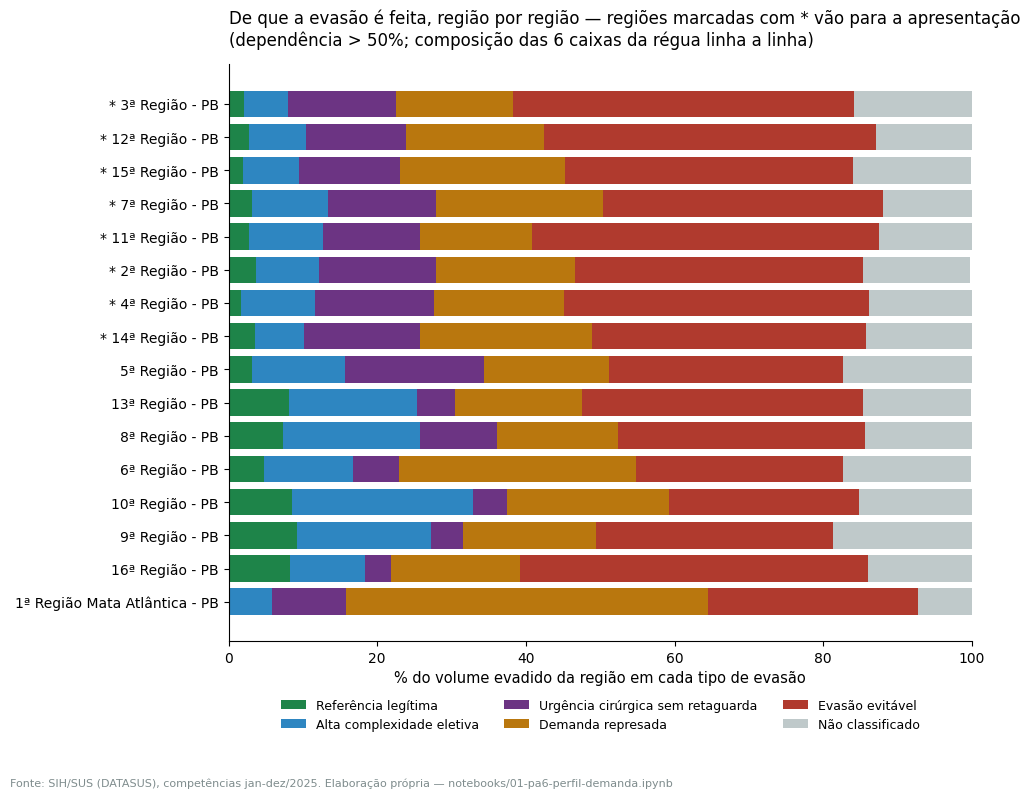

In [9]:
cores_tipo = {
    "Referência legítima": "#1E8449",
    "Alta complexidade eletiva": "#2E86C1",
    "Urgência cirúrgica sem retaguarda": "#6C3483",
    "Demanda represada": "#B9770E",
    "Evasão evitável": "#B03A2E",
    "Não classificado": "#BFC9CA",
}

grafico2 = recomendacao.sort_values("indice_dependencia_pct", ascending=True).reset_index(drop=True)
grafico2["rotulo_regiao"] = grafico2.apply(
    lambda r: ("* " if r["prioritaria_apresentacao"] else "") + r["regiao"], axis=1
)

fig2, ax2 = plt.subplots(figsize=(10, 8))
esquerda = pd.Series(0.0, index=grafico2.index)
for tipo, cor in cores_tipo.items():
    valores = grafico2[f"pct_{tipo}"]
    ax2.barh(grafico2["rotulo_regiao"], valores, left=esquerda, color=cor, label=tipo)
    esquerda = esquerda + valores

ax2.set_xlim(0, 100)
ax2.set_xlabel("% do volume evadido da região em cada tipo de evasão", fontsize=10.5)
ax2.set_title(
    "De que a evasão é feita, região por região — regiões marcadas com * vão para a apresentação\n"
    "(dependência > 50%; composição das 6 caixas da régua linha a linha)",
    fontsize=12, loc="left", pad=14,
)
for lado in ("top", "right"):
    ax2.spines[lado].set_visible(False)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9, frameon=False)

fig2.text(0.01, 0.01,
          "Fonte: SIH/SUS (DATASUS), competências jan-dez/2025. Elaboração própria — "
          "notebooks/01-pa6-perfil-demanda.ipynb", fontsize=8, color="#7F8C8D", ha="left")

fig2.tight_layout(rect=[0, 0.05, 1, 1])
caminho_fig2 = Path("outputs/figures/pa6_tipo_dominante_regioes_prioritarias.png")
fig2.savefig(caminho_fig2, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Salvo: {caminho_fig2}")
plt.show()


## 6. Achados — número + implicação

**1. Classificada linha a linha, a evasão da PB é dominada por lacuna de capacidade
local — não por fila cirúrgica, como a primeira versão (com bug) sugeria.** Com as seis
caixas: "Evasão evitável" 38,8% do volume evadido, "Demanda represada" 20,2%, "Não
classificado" 14,7%, "Urgência cirúrgica sem retaguarda" 13,0% (caixa nova), "Alta
complexidade eletiva" 9,8% e "Referência legítima" 3,7%. **Implicação:** a maior fatia
isolada da evasão paraibana é falta de leito clínico/obstétrico/pediátrico com estrutura
local — não fila de cirurgia eletiva comum.

**2. Entre as 8 regiões prioritárias (dependência > 50%), as 8 continuam com "Evasão
evitável" como tipo dominante mesmo depois da 6ª caixa.** A caixa nova redistribuiu
volume (principalmente tirando de "Não classificado"), mas não mudou o rótulo dominante
de nenhuma das 8 — a 5ª Região é a que mais concentra "Urgência cirúrgica sem
retaguarda" (18,7% do próprio volume evadido, a maior do estado), mas mesmo lá "Evasão
evitável" segue maior (31,5%). **Implicação:** capacidade clínica local continua sendo a
aposta de maior cobertura nas 8 regiões da apresentação; a retaguarda cirúrgica de
urgência é a segunda frente, mais concentrada em algumas regiões do que outras.

**3. "Urgência cirúrgica sem retaguarda" (caixa nova, 13,0% do volume evadido
estadual, 8.768 internações) tem o perfil mais grave entre as caixas com volume
relevante em termos de tempo — permanência média de 5,4 dias, valor médio R$
1.066,20 — e concentra-se mais na 5ª (18,7% do próprio evadido), 4ª (16,1%) e 2ª
Região (15,7%).** A taxa de óbito da caixa como um todo (1,5%) é baixa porque a
maioria chega a tempo depois de atravessar região — o risco está em quem não chega:
não medido aqui, mas é exatamente o argumento clínico por trás de "retaguarda 24h", não
"mutirão".

**4. Depois da 6ª caixa, "Não classificado" caiu de 27,6% para 14,7%** (bateu com a
expectativa de ~13,5%, dentro da margem do que a auditoria anterior media). O maior
perfil residual que sobrou é leito clínico (`ESPEC=03`), média complexidade, urgência,
**com UTI** — 2.326 internações (23,5% do não classificado, 3,4% do volume evadido
total). Não é forçado em nenhuma caixa: "Evasão evitável" exige ausência de UTI por
definição, e esse caso tem UTI — é um paciente clínico grave que precisou de terapia
intensiva fora da própria região, mas sem o `COMPLEX=03` que caracterizaria "Referência
legítima". Reportado como lacuna, não escondido.

**5. A 5ª Região continua sendo a mais grave da tabela, mas por um motivo diferente do
que "Não classificado" sozinho sugeria antes.** Com a régua de 5 caixas, ela era a única
com "Não classificado" dominante (35,9%, 25,8% UTI, 7,0% óbito — a maior mortalidade da
tabela). Com a 6ª caixa, o volume se redistribuiu e "Evasão evitável" passou a dominar
(31,5%, óbito 5,3%) — mas o subgrupo mais letal da região não mudou de lugar: dentro do
que ainda sobra em "Não classificado" na 5ª Região (620 internações), o perfil
cirúrgico/clínico de urgência **com UTI** chega a 35–42% de óbito (`ESPEC=01`: 69 casos,
42,0% óbito; `ESPEC=03`: 122 casos, 35,2% óbito) — o ponto mais grave de toda a análise.
A régua de 6 caixas resolve o rótulo agregado da região, mas não resolve (nem deveria,
fora do escopo aprovado) esse subgrupo específico — ele seria o candidato natural a uma
eventual 7ª caixa, não criada aqui por decisão de escopo.

## Limitações

- **A primeira versão deste notebook tinha um erro metodológico real: classificava
  blocos região×`ESPEC` pelas médias marginais do bloco** (ex.: "79,5% média
  complexidade" + "66,2% eletiva" → "Demanda represada"), o que é uma **falácia de
  composição** — duas médias marginais altas não implicam que as mesmas internações
  tenham as duas características juntas. Além disso, a caixa "Referência legítima"
  exigia >50% de UTI por bloco de especialidade inteira, e UTI é ~9% da base inteira —
  matematicamente impossível de preencher naquela formulação, não um achado sobre os
  dados. A versão corrigida (seção 3) classifica cada internação evadida
  individualmente pelos seus próprios valores, e só então agrega por região.
- **A 6ª caixa ("Urgência cirúrgica sem retaguarda") foi adicionada numa segunda
  rodada**, depois de auditar o que sobrava em "Não classificado" na primeira versão da
  régua linha a linha (5 caixas) e encontrar que 51,2% daquele resíduo era um padrão
  único e coerente: `ESPEC=01` + `COMPLEX=02` + `CAR_INT=02` (urgência) sem UTI. Ela
  entra na ordem de avaliação **depois** de "Alta complexidade eletiva" e **antes** de
  "Demanda represada" — mesma especialidade e complexidade de "Demanda represada", mas
  caráter oposto (urgência, não eletiva): fila eletiva é problema de agenda, urgência
  que atravessa região é problema de retaguarda.
- **"Não classificado" em 14,7% ainda é uma lacuna real da régua aprovada**, concentrada
  em leito clínico/pediátrico de urgência **com UTI** (ver achado 4) — não forçado em
  nenhuma das seis caixas.
- **A 5ª Região tem um subgrupo residual de altíssima letalidade (35–42% de óbito, ver
  achado 5) que nenhuma das seis caixas resolve** — fica documentado aqui para a defesa,
  não escondido dentro de um rótulo agregado "Evasão evitável" que sozinho sugeriria
  óbito de 5,3%.
- **`ESPEC` é uma categoria grossa** (10 valores para todo o hospital) — mesmo
  corrigida para linha a linha, a régua ainda usa `ESPEC` como um dos critérios de
  algumas caixas; `CAR_INT`/`COMPLEX`/UTI já entram na régua justamente para diferenciar
  dentro da especialidade.
- **O recorte exclui não-residentes da PB** (1.502 linhas) e não inclui paraibanos
  internados fora do estado (PE/RN/CE, tratado em outro notebook, PA-5) — os números
  aqui são só sobre a evasão **dentro** da PB.
- **A ordem de prioridade das seis caixas (seção 3) é uma decisão deste notebook**, não
  do backlog original — declarada explicitamente porque a régua descreve os perfis
  qualitativamente, sem definir o que fazer quando uma internação bateria em mais de
  uma condição ao mesmo tempo. **Este é o método final do PA6** — congelado a partir
  desta rodada.
- **Nenhuma taxa de óbito por caixa deste notebook sustenta leitura causal.** A régua
  classifica **tipo de necessidade assistencial** (que tipo de resposta a Secretaria
  deveria dar), não desfecho clínico — e não foi desenhada, nem poderia ser com o SIH
  sozinho, para medir se evadir muda o risco de morrer. Ver seção 7 (teste de robustez)
  para o porquê explícito: comparado contra quem tem o mesmo perfil clínico e **não**
  evadiu, quem evade morre igual ou menos — o oposto do que "42% de óbito" lido isolado
  sugere.

## 7. Teste de robustez: a evasão piora o desfecho?

O achado 5 (seção 6) mostrou 42,0% de óbito em cirúrgico de urgência com UTI evadido
da 5ª Região — o número mais alto de toda a análise. Lido sozinho, ele sugere que viajar
para outra região mata. **Esse é exatamente o tipo de leitura que este notebook não pode
sustentar sem testar.** Faltava comparar contra quem tem o mesmo perfil clínico e **não**
evadiu — só assim dá pra saber se o número é sobre gravidade do caso ou sobre o
deslocamento em si.

**O teste:** dentro do recorte `CAR_INT='02'` (urgência) e uso de UTI — o estrato mais
grave que a base tem —, comparar óbito e permanência entre quem evadiu e quem não
evadiu, no estado inteiro, por especialidade (`ESPEC` 01 e 03) e na 5ª Região
especificamente.

In [10]:
base_robustez = df[(df["CAR_INT"] == "02") & (df["uti_flag"])].copy()

def resume_grupo(sub, recorte):
    g = sub.groupby("evadiu").agg(
        n=("MORTE", "size"),
        taxa_obito_pct=("MORTE", lambda s: 100 * s.mean()),
        permanencia_media=("DIAS_PERM", "mean"),
    ).reset_index()
    g["grupo"] = g["evadiu"].map({False: "nao_evadiu", True: "evadiu"})
    g["recorte"] = recorte
    return g[["recorte", "grupo", "n", "taxa_obito_pct", "permanencia_media"]]

linhas_robustez = [
    resume_grupo(base_robustez, "Estado (CAR_INT=02 + UTI)"),
    resume_grupo(base_robustez[base_robustez["ESPEC"] == "01"], "ESPEC=01 Cirúrgico (CAR_INT=02 + UTI)"),
    resume_grupo(base_robustez[base_robustez["ESPEC"] == "03"], "ESPEC=03 Clínico (CAR_INT=02 + UTI)"),
    resume_grupo(
        base_robustez[(base_robustez["regiao_res"] == "5ª Região - PB") & (base_robustez["ESPEC"] == "03")],
        "5ª Região, ESPEC=03 Clínico (CAR_INT=02 + UTI)",
    ),
]
robustez = pd.concat(linhas_robustez, ignore_index=True).round(1)

Path("outputs/tables").mkdir(parents=True, exist_ok=True)
caminho_robustez = Path("outputs/tables/pa6_teste_robustez_desfecho.csv")
robustez.to_csv(caminho_robustez, index=False, encoding="utf-8")
print(f"Salvo: {caminho_robustez} ({len(robustez)} linhas)")

robustez


Salvo: outputs\tables\pa6_teste_robustez_desfecho.csv (8 linhas)


,recorte,grupo,n,taxa_obito_pct,permanencia_media
0,Estado (CAR_INT=02 + UTI),nao_evadiu,10821,29.4,12.2
1,Estado (CAR_INT=02 + UTI),evadiu,5885,24.7,11.4
2,ESPEC=01 Cirúrgico (CAR_INT=02 + UTI),nao_evadiu,1506,27.8,11.4
3,ESPEC=01 Cirúrgico (CAR_INT=02 + UTI),evadiu,1046,27.2,11.1
4,ESPEC=03 Clínico (CAR_INT=02 + UTI),nao_evadiu,6060,41.7,12.9
5,ESPEC=03 Clínico (CAR_INT=02 + UTI),evadiu,2495,39.3,11.3
6,"5ª Região, ESPEC=03 Clínico (CAR_INT=02 + UTI)",nao_evadiu,150,42.7,13.9
7,"5ª Região, ESPEC=03 Clínico (CAR_INT=02 + UTI)",evadiu,139,37.4,12.0


**Leitura do contraste.** Em todo recorte testado, quem **não** evadiu morreu
igual ou mais do que quem evadiu — nunca o contrário:

- **Estado inteiro:** 29,4% de óbito em quem ficou vs 24,7% em quem evadiu.
- **`ESPEC=01` (cirúrgico):** 27,8% vs 27,2% — praticamente empatado.
- **`ESPEC=03` (clínico):** 41,7% vs 39,3%.
- **5ª Região, `ESPEC=03`:** 42,7% (ficou) vs 37,4% (evadiu) — o mesmo estrato clínico
  que rendeu o "42% de óbito" do achado 5 tem óbito **maior** entre quem não evadiu.

**Duas explicações concorrentes, nenhuma comprovável só com o SIH:**

1. **Quem é transferido chega a hospital de maior porte e recurso** — mais UTI
   disponível, mais especialista, mais equipamento. A transferência protegeria.
2. **Viés de seleção na transferência** — só é transferido quem está estável o
   suficiente para aguentar o transporte; quem está morrendo rápido demais para
   esperar remoção fica e morre onde está, contado aqui como "não evadiu". Se for isso,
   o grupo "não evadiu" não é mais grave por ficar — ele parece mais grave porque
   inclui os casos que nunca tiveram chance de evadir.

**O dado não decide entre as duas.** O SIH não tem escore de gravidade de admissão
(APACHE, SOFA ou equivalente) nem horário do agravamento em relação ao horário da
transferência — não dá para saber se quem ficou já chegou mais grave ou piorou depois.
Por isso este notebook **não afirma** "a evasão piora o desfecho" **nem** o inverso "a
transferência protege". A comparação é observacional, confundida por gravidade do caso,
e a régua da seção 3 continua sendo sobre **tipo de necessidade assistencial** — não
sobre risco de morte. Qualquer leitura causal das taxas de óbito por caixa, nesta ou em
análises anteriores deste notebook, está fora do que os dados suportam; isso está
registrado também na seção de Limitações (seção 6).